# imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn import datasets
from sklearn.svm import SVC
from sklearn import metrics

# Data loading

In [3]:
df = pd.read_csv('Dataset.csv')
df

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,660997.txt,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,...,1,0,1,51,7,21,187,2,191,1
235791,77185.txt,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,...,1,0,0,50,1,7,88,0,31,1
235792,622132.txt,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,...,0,0,1,27,10,30,58,2,67,1
235793,7503962.txt,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,...,0,0,0,0,0,3,0,0,0,0


# 1 Data preprocessing

## 1.1 Missing values

In [17]:
# since the data is huge. i can drop the null values
df = df.dropna()
print(df.columns)
print(df.info)
print(df.describe)

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')
<bound

## 1.2 Removing Duplicates

In [5]:
df = df.drop_duplicates()

# 1.3 Removing useless info

In [6]:
df = df.drop(df.select_dtypes(include=['object']).columns, axis=1)
# df = df.drop(columns=['FILENAME'])
# df = df.drop(columns=['URL'])
# df = df.drop(columns=['Domain'])
# df = df.drop(columns=['TLD'])

print(df.columns)
print(df)


# isDomainIP = df[df['IsDomainIP'] == 1]
# arr = [i for i in isDomainIP['label']]
# arr
# isDomainIP.count()
# print(isDomainIPTrue)

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')
      

## 1.4 Exploratory Data Analysis

In [7]:
phish = df[df["label"] == 1]
print(len(phish))

legit = df[df["label"] == 0]
print(len(legit))

134850
100945


# plots

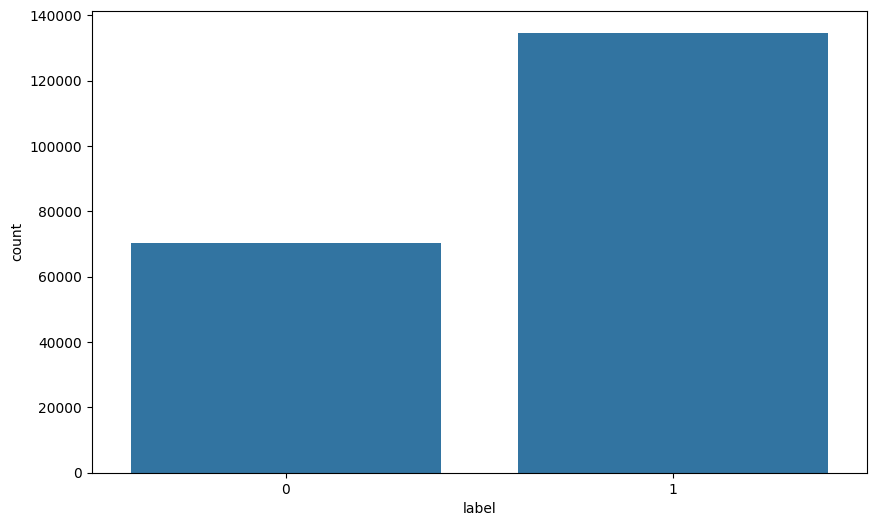

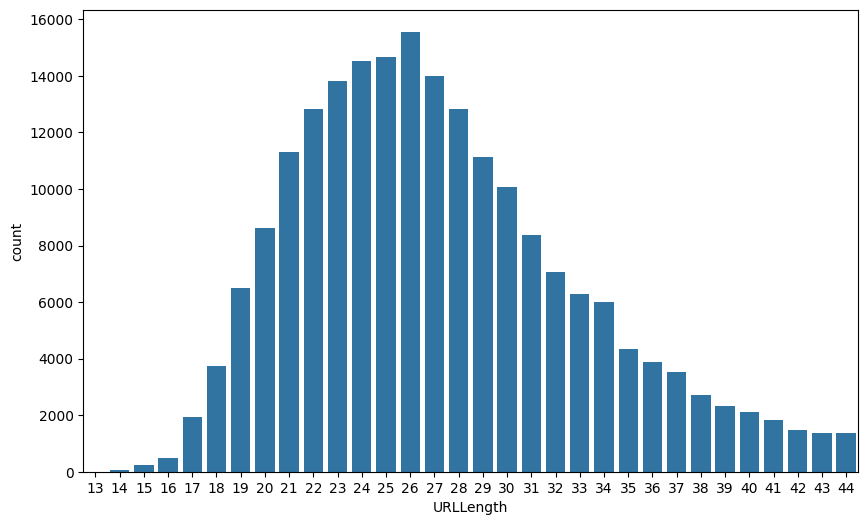

In [8]:
df = df[df["URLLength"] < 45]

plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df)
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(x='URLLength', data=df)
plt.show()

# KNN

In [9]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# print(X)
# print(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# scaler = MinMaxScaler(feature_range=(0, 1))
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [12]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [13]:
y_pred = knn.predict(X_test)


In [14]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
# knn.score(X_test, y_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred)) 

Accuracy: 0.9979756591302651
[[13929    40]
 [   43 26989]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13969
           1       1.00      1.00      1.00     27032

    accuracy                           1.00     41001
   macro avg       1.00      1.00      1.00     41001
weighted avg       1.00      1.00      1.00     41001



# SVM

In [15]:
# SVM model
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = svm_model.predict(X_test)

In [16]:
# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
confusion_matrix_svm = confusion_matrix(y_test, y_pred)
classification_report_svm = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix_svm)
print("Classification Report:")
print(classification_report_svm)

Accuracy: 0.9999268310529011
Confusion Matrix:
[[13967     2]
 [    1 27031]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13969
           1       1.00      1.00      1.00     27032

    accuracy                           1.00     41001
   macro avg       1.00      1.00      1.00     41001
weighted avg       1.00      1.00      1.00     41001

